In [31]:
using JLD2
using Plots
using Statistics
using Printf

gr()


Plots.GRBackend()

In [32]:
cutoffs = ["1.0e-4", "1.0e-5", "1.0e-6", "1.0e-7", "1.0e-8", "1.0e-9", "1.0e-10", "1.0e-11", "1.0e-12", "1.0e-13", "1.0e-14"]
sigma_list = [0.2, 0.02, 0.002, 0.0002, 0.0]


data_dict = Dict()
results = Dict()

for c in cutoffs
    filename = joinpath(@__DIR__, "truncation_$(c).jld2")
    
    if isfile(filename)
        data = JLD2.load(filename)
        data_dict[c] = data
        
        results[c] = data["entanglement_results"]
        var_name = "results_" * replace(c, "-" => "_", "." => "_")
        eval(:($(Symbol(var_name)) = $(results[c])))
        
    else
        println("Warning: File $filename not found.")
    end
end

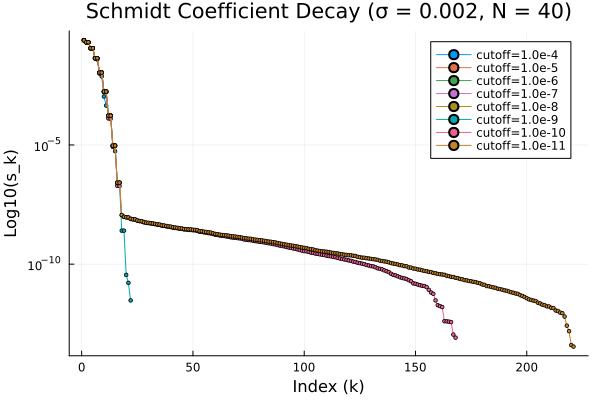

In [33]:
"""
Plots the Schmidt coefficients (Entanglement Spectrum) on a log scale 
for a specific sigma and N across all truncation cutoffs.
"""
function plot_schmidt_truncation_comparison(target_sigma, target_N, results_dict, cutoffs_list)
    p = plot(
        title="Schmidt Coefficient Decay (σ = $target_sigma, N = $target_N)",
        xlabel="Index (k)",
        ylabel="Log10(s_k)",
        yaxis=:log10,
        legend=:topright,
        grid=true,
        lw=2
    )


    
    for c in cutoffs_list
        if haskey(results_dict, c) && haskey(results_dict[c], target_sigma)
            sigma_data = results_dict[c][target_sigma]
            
            if haskey(sigma_data, target_N)
                coeffs = sigma_data[target_N] .^2
                
                valid_indices = findall(x -> x > 1e-20, coeffs)
                
                plot!(
                    p, 
                    valid_indices, 
                    coeffs[valid_indices], 
                    label="cutoff=$c", 
                    marker=:circle, 
                    markersize=2,
                    alpha=1
                )
            end
        end
    end
    return p
end

p_schmidt = plot_schmidt_truncation_comparison(0.002, 40, results, cutoffs)

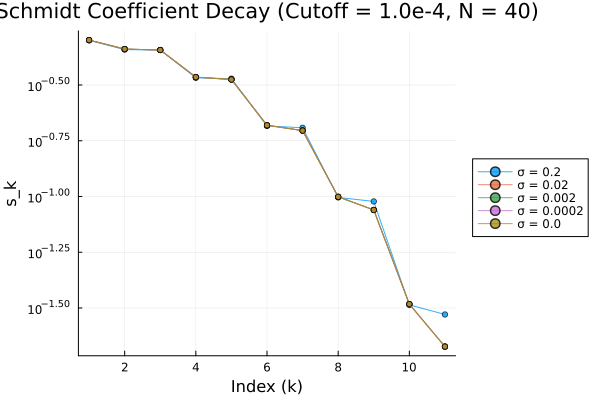

In [34]:
"""
Plots the Schmidt coefficients (Entanglement Spectrum) on a log scale 
for all available sigma values at a specific N and a chosen truncation cutoff.
"""
function plot_schmidt_sigma_comparison(target_cutoff, target_N, results_dict)
    if !haskey(results_dict, target_cutoff)
        println("Error: Cutoff $target_cutoff not found in results.")
        return nothing
    end

    p = plot(
        title="Schmidt Coefficient Decay (Cutoff = $target_cutoff, N = $target_N)",
        xlabel="Index (k)",
        ylabel="s_k",
        yaxis=:log10,
        legend=:outerright,
        grid=true,
        lw=2
    )

    # Get all sigma values for this specific cutoff and sort them
    sigmas = sort(collect(keys(results_dict[target_cutoff])), rev = true)

    for σ in sigmas
        sigma_data = results_dict[target_cutoff][σ]
        
        if haskey(sigma_data, target_N)
            coeffs = sigma_data[target_N]
            
            # Filter out very small values to keep the log plot clean
            valid_indices = findall(x -> x > 1e-20, coeffs)
            
            plot!(
                p, 
                valid_indices, 
                coeffs[valid_indices], 
                label="σ = $σ", 
                marker=:circle, 
                markersize=3,
                alpha=0.8
            )
        end
    end
    return p
end


p_sigma_comp = plot_schmidt_sigma_comparison("1.0e-4", 40, results)

In [35]:
function renyi_entropy(coeffs, α)
    probs = coeffs .^ 2
    # Filter for numerical stability (avoid log(0))
    probs = probs[probs .> 1e-30]
    
    if α == 1.0
        return -sum(probs .* log.(probs))
    elseif α == 0.0
        return log(length(probs))
    elseif α == Inf
        return -log(maximum(probs))
    else
        return (1 / (1 - α)) * log(sum(probs .^ α))
    end
end

# Generalised plotting function
function plot_entropy_task(target_sigma, results_dict, cutoffs_list, α, title_str, ylabel_str)
    p = plot(title="$title_str (σ = $target_sigma)", 
             xlabel="System Size (N)", ylabel=ylabel_str,
             legend=:outerright, grid=true, lw=1.5)

    for c in cutoffs_list
        haskey(results_dict, c) || continue
        haskey(results_dict[c], target_sigma) || continue
        
        sigma_data = results_dict[c][target_sigma]
        sorted_Ns = sort(collect(keys(sigma_data)))
        
        # Optimised map: applies renyi_entropy to each N's vector
        values = [renyi_entropy(sigma_data[n], α) for n in sorted_Ns]
        
        plot!(p, sorted_Ns, values, label="cutoff=$c", marker=:circle, markersize=3)
    end
    return p
end



plot_entropy_task (generic function with 1 method)

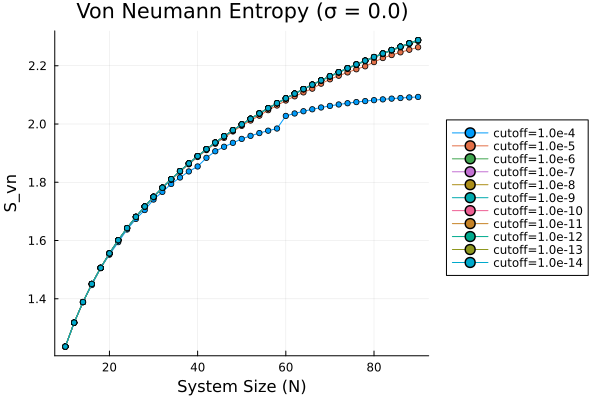

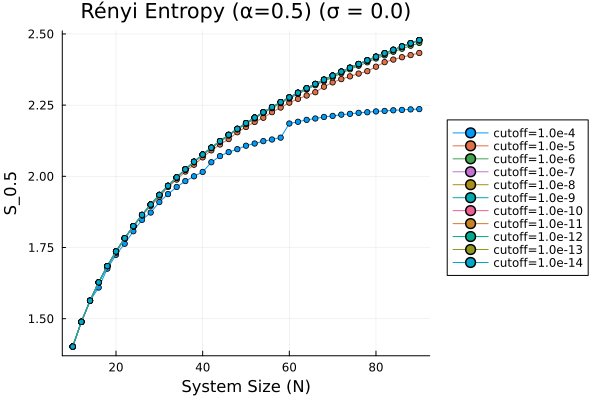

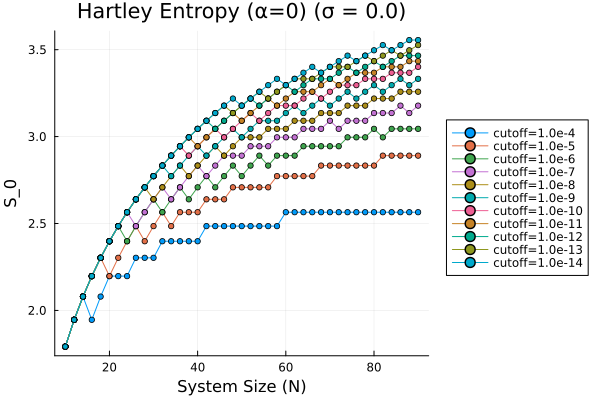

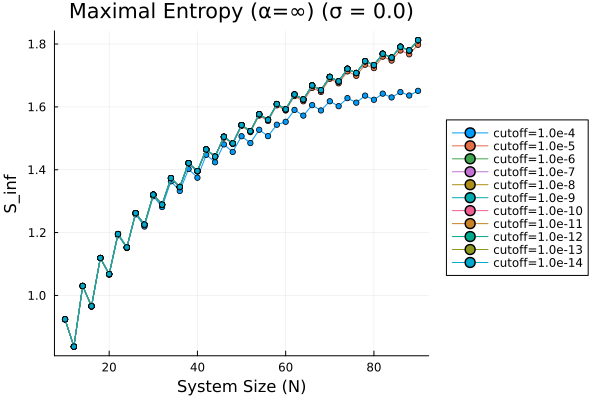

In [36]:
function plot_von_neumann(σ, res, cuts)
    plot_entropy_task(σ, res, cuts, 1.0, "Von Neumann Entropy", "S_vn")
end
p_vn = plot_von_neumann(0.0, results, cutoffs)
display(p_vn)



function plot_renyi_05(σ, res, cuts)
    plot_entropy_task(σ, res, cuts, 0.5, "Rényi Entropy (α=0.5)", "S_0.5")
end
p_r05 = plot_renyi_05(0.0, results, cutoffs)
display(p_r05)



function plot_hartley(σ, res, cuts)
    plot_entropy_task(σ, res, cuts, 0.0, "Hartley Entropy (α=0)", "S_0")
end
p_hartley = plot_hartley(0.0, results, cutoffs)
display(p_hartley)



function plot_maximal(σ, res, cuts)
    plot_entropy_task(σ, res, cuts, Inf, "Maximal Entropy (α=∞)", "S_inf")
end
p_max = plot_maximal(0.0, results, cutoffs)
display(p_max)

In [37]:
function calculate_renyi(coeffs, α)

    probs = @views coeffs .^ 2
    probs = probs[probs .> 1e-30]
    
    if α == 1.0      # Von Neumann
        return -sum(probs .* log.(probs))
    elseif α == 0.0  # Hartley
        return log(length(probs))
    elseif α == Inf  # Maximal
        return -log(maximum(probs))
    else             # General Renyi (e.g. 0.5)
        return (1 / (1 - α)) * log(sum(probs .^ α))
    end
end

function plot_entropy_all_sigmas_task(target_cutoff, results_dict, α, title_str, ylabel_str)
    # Validate cutoff
    !haskey(results_dict, target_cutoff) && return println("Error: Cutoff $target_cutoff not found.")
    
    p = plot(title="$title_str (Truncation: $target_cutoff)", 
             xlabel="System Size (N)", ylabel=ylabel_str,
             legend=:outerright, grid=true, lw=1.5)

    # Automatically get and sort all available sigma values
    sigmas = sort(collect(keys(results_dict[target_cutoff])))

    for σ in sigmas
        sigma_data = results_dict[target_cutoff][σ]
        sorted_Ns = sort(collect(keys(sigma_data)))
        
        values = [calculate_renyi(sigma_data[n], α) for n in sorted_Ns]
        
        plot!(p, sorted_Ns, values, label="σ=$σ", marker=:circle, markersize=3)
    end
    return p
end

plot_entropy_all_sigmas_task (generic function with 1 method)

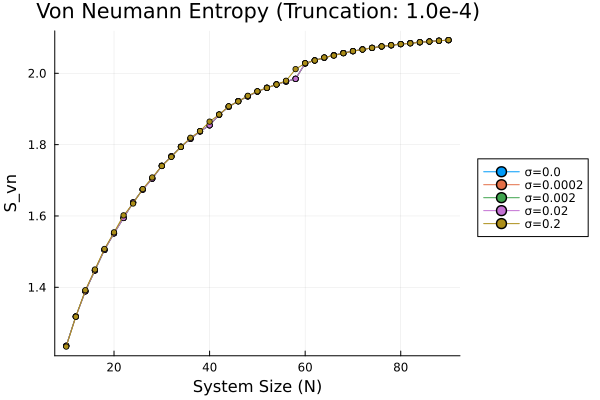

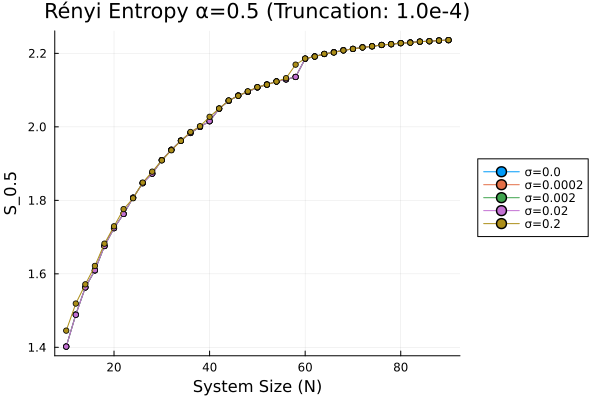

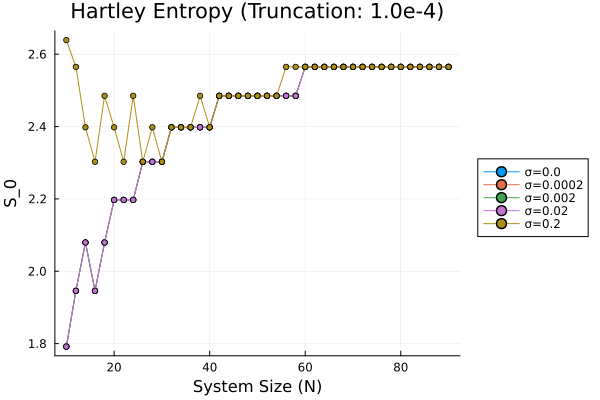

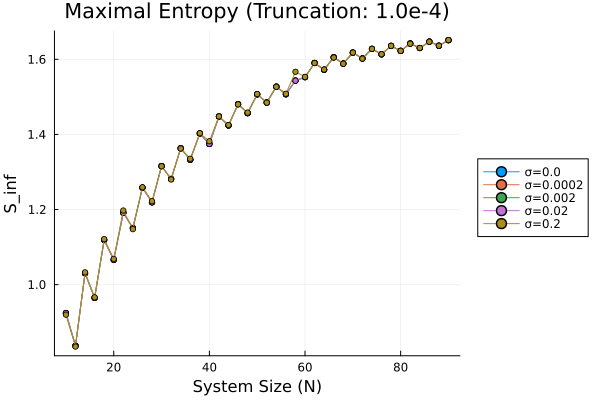

In [38]:
function plot_von_neumann_sigmas(cutoff, res)
    plot_entropy_all_sigmas_task(cutoff, res, 1.0, "Von Neumann Entropy", "S_vn")
end
p_vn_sigmas = plot_von_neumann_sigmas("1.0e-4", results)
display(p_vn_sigmas)



function plot_renyi_05_sigmas(cutoff, res)
    plot_entropy_all_sigmas_task(cutoff, res, 0.5, "Rényi Entropy α=0.5", "S_0.5")
end
p_r05_sigmas = plot_renyi_05_sigmas("1.0e-4", results)
display(p_r05_sigmas)



function plot_hartley_sigmas(cutoff, res)
    plot_entropy_all_sigmas_task(cutoff, res, 0.0, "Hartley Entropy", "S_0")
end
p_hart_sigmas = plot_hartley_sigmas("1.0e-4", results)
display(p_hart_sigmas)



function plot_maximal_sigmas(cutoff, res)
    plot_entropy_all_sigmas_task(cutoff, res, Inf, "Maximal Entropy", "S_inf")
end
p_max_sigmas = plot_maximal_sigmas("1.0e-4", results)
display(p_max_sigmas)

In [39]:
"""
Revised Deviation Index Calculation.
Instead of absolute difference, it looks for the index where the 
noisy spectrum begins to plateau relative to the baseline.
"""
function calculate_deviation_index(results_dict, cutoffs_list, target_N; tol=1e-10)
    master_deviation_dict = Dict{String, Dict{Float64, Int}}()

    for cutoff in cutoffs_list
        if !haskey(results_dict, cutoff) continue end
        cutoff_data = results_dict[cutoff]
        
        if !haskey(cutoff_data, 0.0) || !haskey(cutoff_data[0.0], target_N)
            continue
        end
        
        baseline = cutoff_data[0.0][target_N]
        sigmas = sort(collect(keys(cutoff_data)), rev=true)
        cutoff_deviations = Dict{Float64, Int}()

        for σ in sigmas
            σ == 0.0 && continue 
            if !haskey(cutoff_data[σ], target_N) continue end

            current = cutoff_data[σ][target_N]
            len = min(length(baseline), length(current))
            

            idx = findfirst(k -> begin
                diff = abs(current[k] - baseline[k])

                return diff > tol && baseline[k] < 0.1 
            end, 1:len)
            
            if isnothing(idx)
                idx = findfirst(k -> current[k] < (tol * 10), 1:len)
            end

            cutoff_deviations[σ] = isnothing(idx) ? 0 : idx
        end
        master_deviation_dict[cutoff] = cutoff_deviations
    end
    
    return master_deviation_dict
end

all_deviations = calculate_deviation_index(results, cutoffs, 40, tol=1e-8)

Dict{String, Dict{Float64, Int64}} with 11 entries:
  "1.0e-7"  => Dict(0.002=>10, 0.2=>10, 0.02=>10, 0.0002=>10)
  "1.0e-6"  => Dict(0.002=>10, 0.2=>10, 0.02=>10, 0.0002=>10)
  "1.0e-4"  => Dict(0.002=>8, 0.2=>8, 0.02=>8, 0.0002=>8)
  "1.0e-13" => Dict(0.0002=>10)
  "1.0e-10" => Dict(0.002=>10, 0.0002=>10)
  "1.0e-12" => Dict(0.0002=>10)
  "1.0e-9"  => Dict(0.002=>10, 0.02=>10, 0.0002=>10)
  "1.0e-8"  => Dict(0.002=>10, 0.2=>10, 0.02=>10, 0.0002=>10)
  "1.0e-14" => Dict(0.0002=>10)
  "1.0e-5"  => Dict(0.002=>10, 0.2=>10, 0.02=>10, 0.0002=>10)
  "1.0e-11" => Dict(0.002=>10, 0.0002=>10)

In [40]:
"""
Calculates the tail weight for all sigmas and truncations based on deviation indices.
Returns: Dict{String (Cutoff) => Dict{Float64 (Sigma) => Float64 (Weight)}}
"""
function calculate_all_tail_weights(results_dict, deviation_results, target_N)
    master_weight_dict = Dict{String, Dict{Float64, Float64}}()

    for (cutoff, sigmas_dict) in deviation_results
        if !haskey(results_dict, cutoff)
            continue
        end

        cutoff_weights = Dict{Float64, Float64}()

        for (σ, deviation_idx) in sigmas_dict
            # If the deviation index is 0, we can't calculate a tail; skip or set to 0.0
            if deviation_idx == 0 || !haskey(results_dict[cutoff][σ], target_N)
                cutoff_weights[σ] = 0.0
                continue
            end

            # Get the Schmidt coefficients for this specific case
            coeffs = results_dict[cutoff][σ][target_N]

            # tail_weight = sum(s_i^2) from deviation_idx to end
            weight = @views sum(abs2, coeffs[deviation_idx:end])
            
            cutoff_weights[σ] = weight
        end

        master_weight_dict[cutoff] = cutoff_weights
    end

    return master_weight_dict
end


all_weights = calculate_all_tail_weights(results, all_deviations, 40)

# for (cutoff, sigmas_dict) in all_weights
#     println("Truncation: $cutoff")
#     for (σ, weight) in sigmas_dict
#         @printf("  σ = %.5f | Tail Weight: %.2e\n", σ, weight)
#     end
# end

Dict{String, Dict{Float64, Float64}} with 11 entries:
  "1.0e-7"  => Dict(0.002=>0.00384544, 0.2=>0.00633197, 0.02=>0.00384912, 0.000…
  "1.0e-6"  => Dict(0.002=>0.00381284, 0.2=>0.00571048, 0.02=>0.00381591, 0.000…
  "1.0e-4"  => Dict(0.002=>0.019026, 0.2=>0.0207703, 0.02=>0.0190341, 0.0002=>0…
  "1.0e-13" => Dict(0.0002=>0.00384752)
  "1.0e-10" => Dict(0.002=>0.00384775, 0.0002=>0.00384752)
  "1.0e-9"  => Dict(0.002=>0.00384751, 0.02=>0.00387579, 0.0002=>0.00384751)
  "1.0e-8"  => Dict(0.002=>0.00384739, 0.2=>0.00635799, 0.02=>0.00387388, 0.000…
  "1.0e-12" => Dict(0.0002=>0.00384752)
  "1.0e-14" => Dict(0.0002=>0.00384752)
  "1.0e-5"  => Dict(0.002=>0.00355929, 0.2=>0.00366404, 0.02=>0.00356094, 0.000…
  "1.0e-11" => Dict(0.002=>0.00384777, 0.0002=>0.00384752)

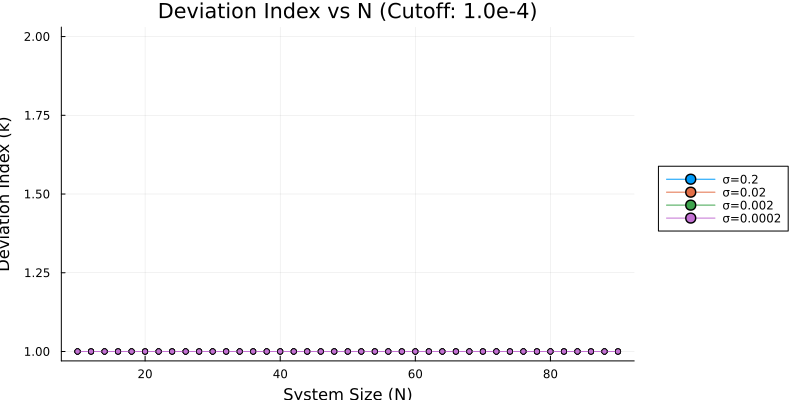

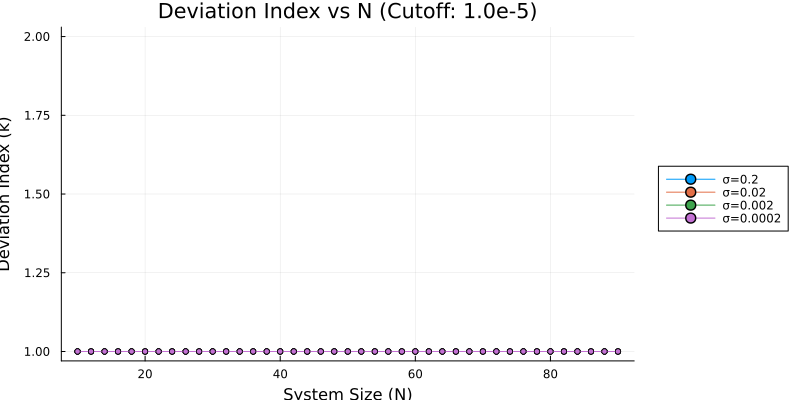

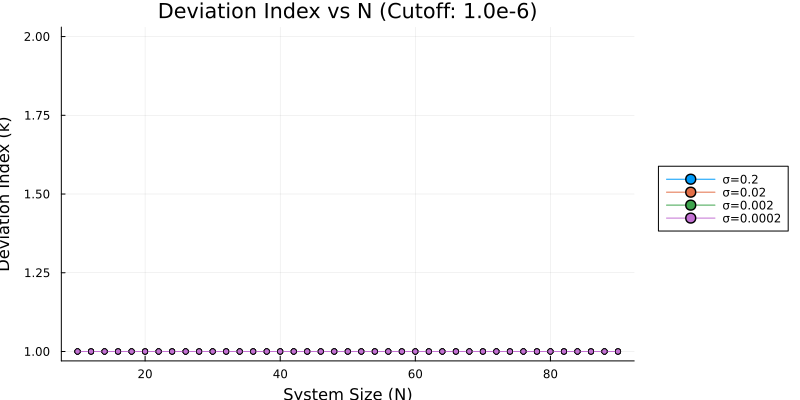

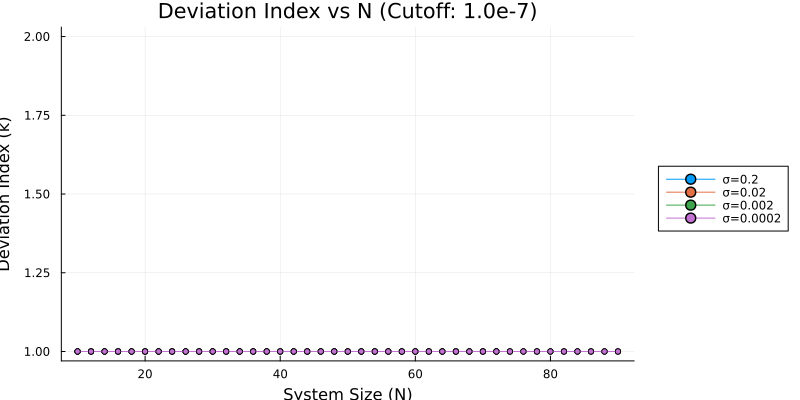

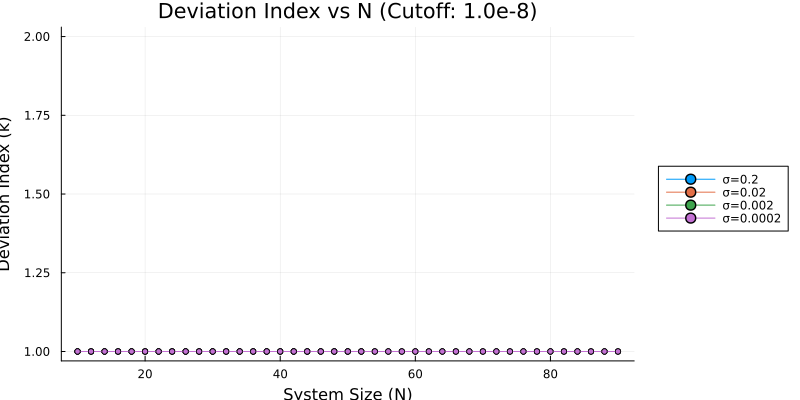

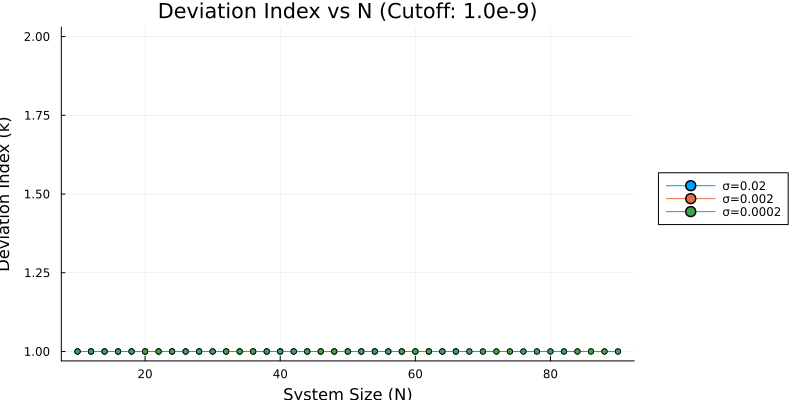

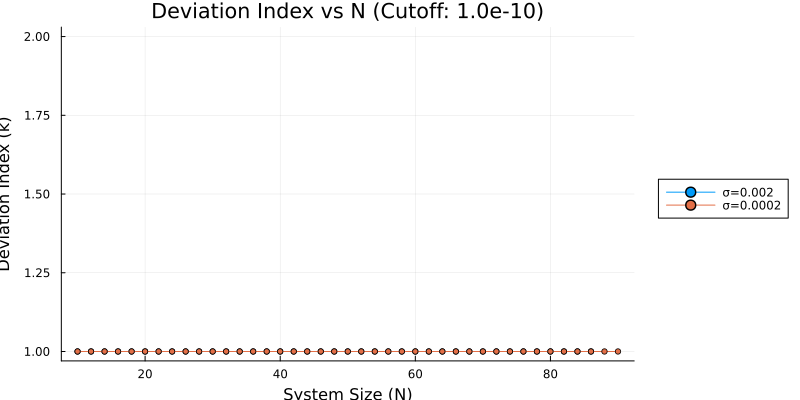

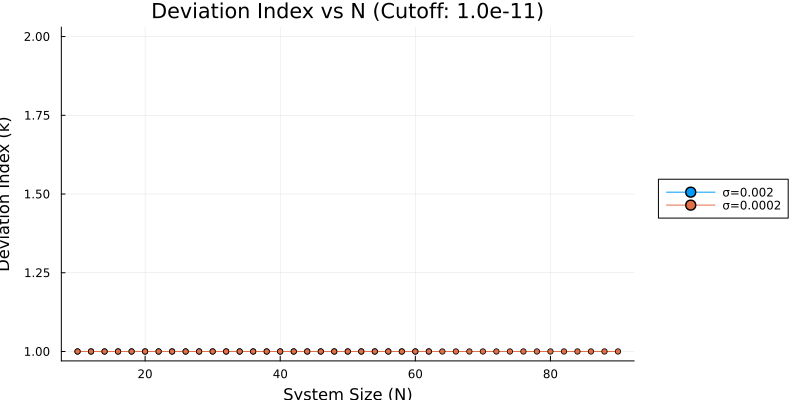

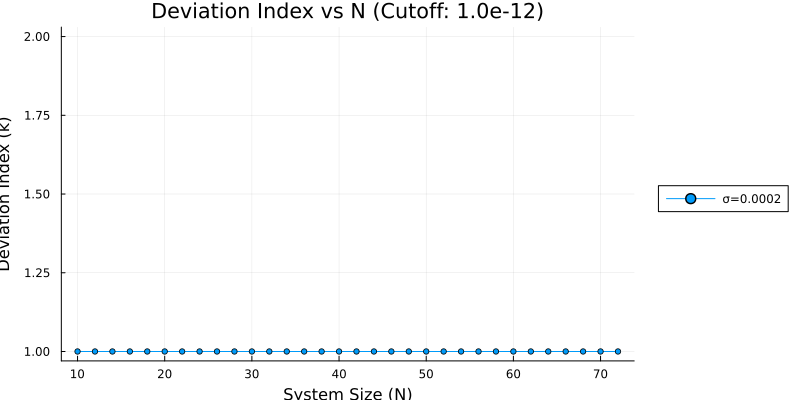

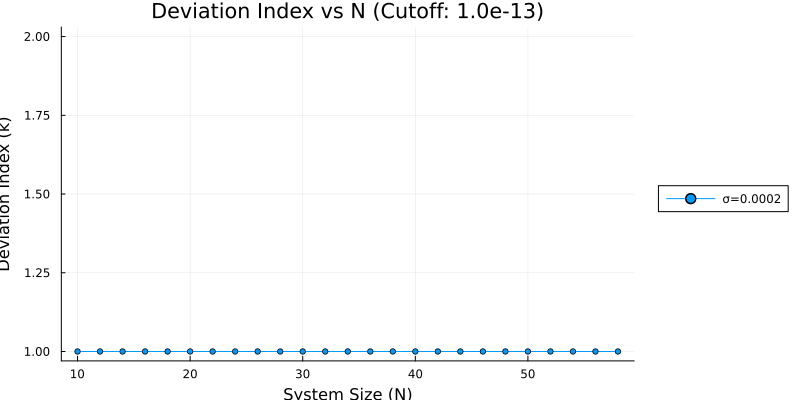

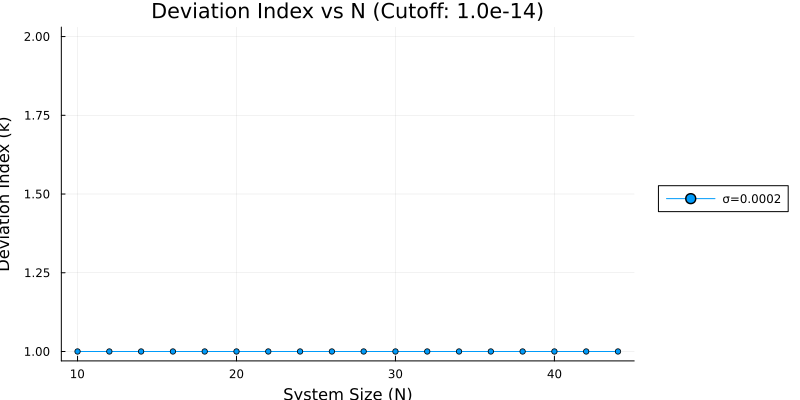

In [41]:
function plot_deviation(results_dict, cutoffs_list; tol=1e-10)
    for cutoff in cutoffs_list
        haskey(results_dict, cutoff) || continue
        cutoff_data = results_dict[cutoff]
        !haskey(cutoff_data, 0.0) && continue
        
        p = plot(
            title="Deviation Index vs N (Cutoff: $cutoff)",
            xlabel="System Size (N)",
            ylabel="Deviation Index (k)",
            legend=:outerright,
            grid=true,
            lw=1.5,
            size=(800, 400)
        )
        
        # Plot sigmas in reverse (most noise first, 0.0 on top)
        sigmas = sort(collect(keys(cutoff_data)), rev=true)

        for σ in sigmas
            σ == 0.0 && continue 
            available_Ns = sort(collect(intersect(keys(cutoff_data[σ]), keys(cutoff_data[0.0]))))
            
            y_vals = Float64[]
            x_vals = Int[]
            
            for n in available_Ns
                baseline = cutoff_data[0.0][n]
                current = cutoff_data[σ][n]
                idx = findfirst(k -> abs(current[k] - baseline[k]) > tol, 1:min(length(baseline), length(current)))
                push!(y_vals, isnothing(idx) ? 0.0 : Float64(idx))
                push!(x_vals, n)
            end
            
            if !isempty(x_vals)
                plot!(p, x_vals, y_vals, label="σ=$σ", marker=:circle, markersize=3)
            end
        end
        display(p) 
    end
end

plot_deviation(results, cutoffs)

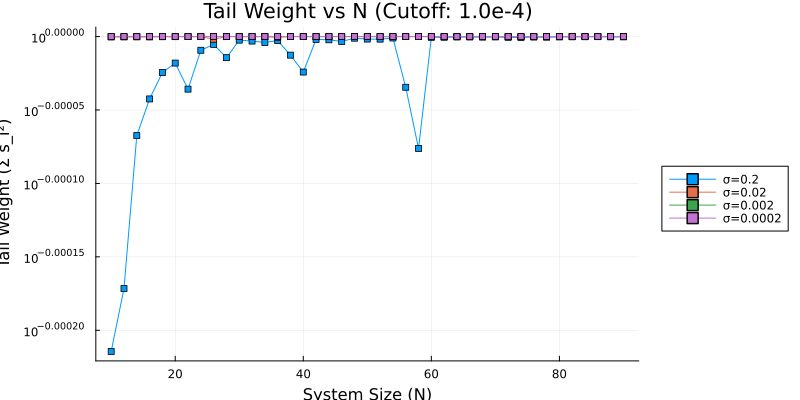

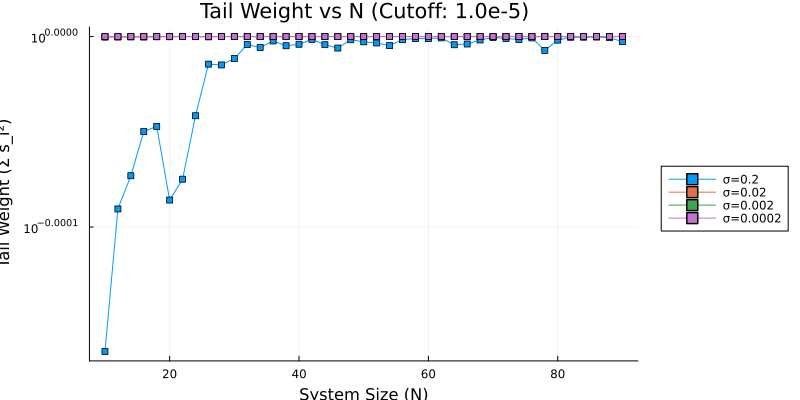

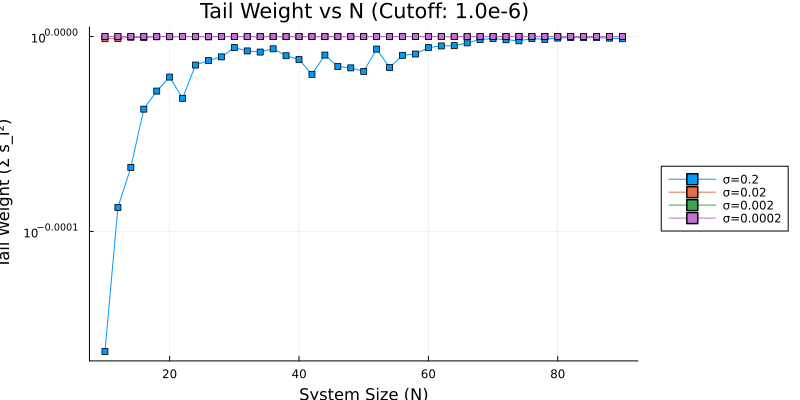

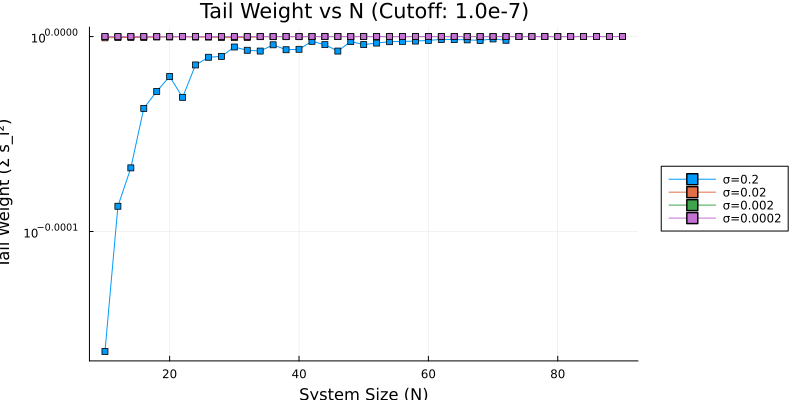

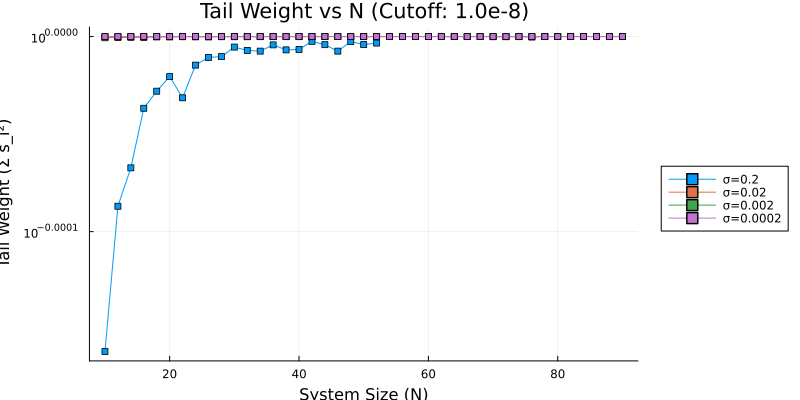

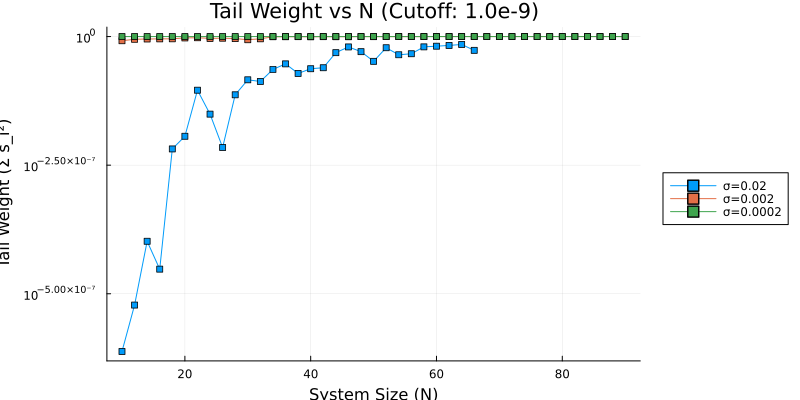

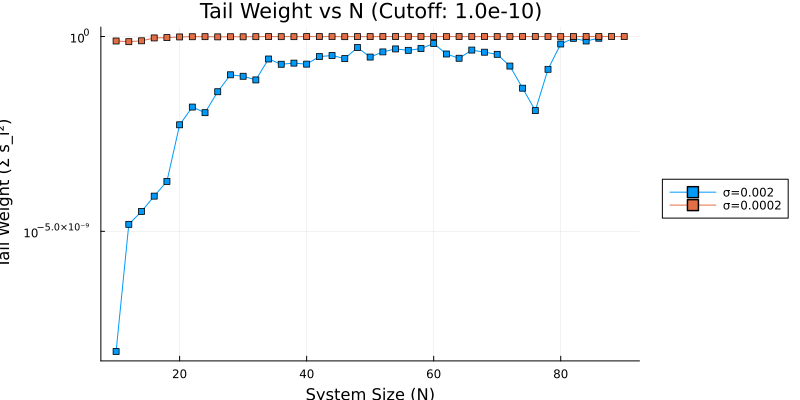

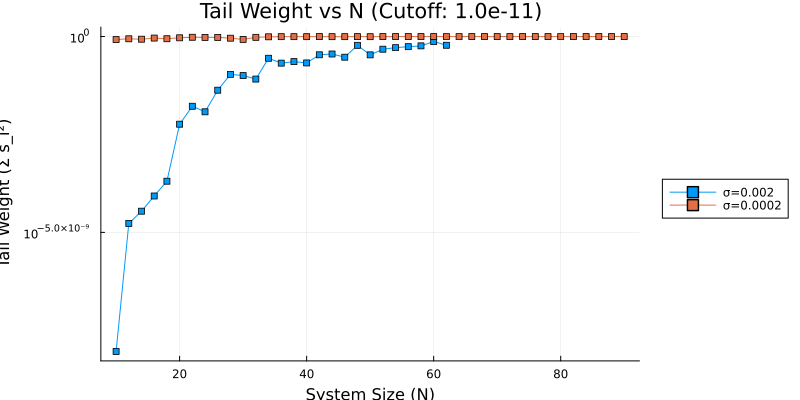

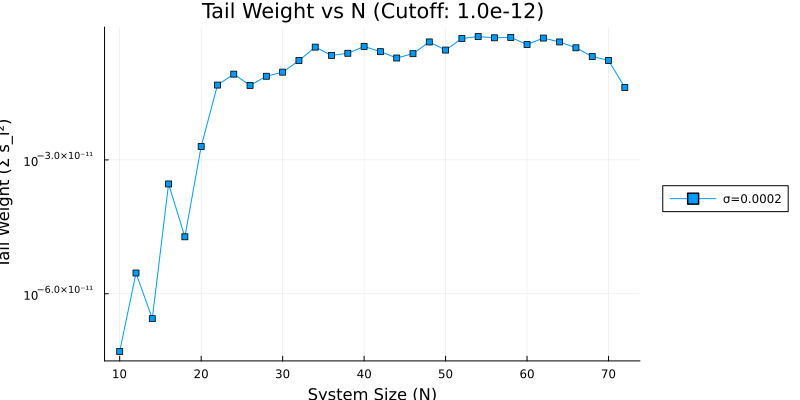

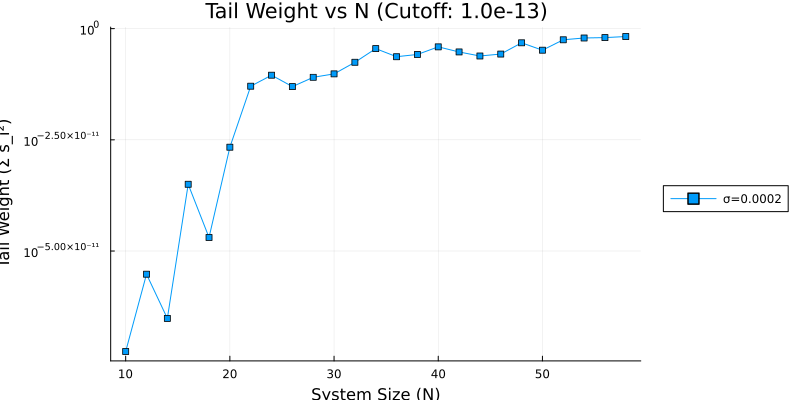

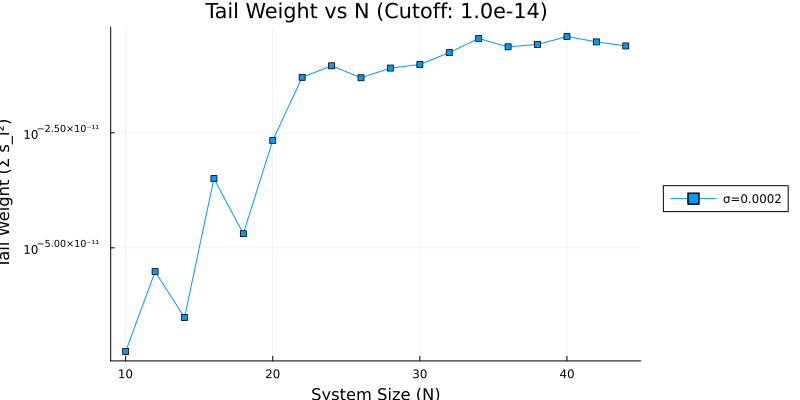

In [42]:
function plot_tail_weight(results_dict, cutoffs_list; tol=1e-10)
    for cutoff in cutoffs_list
        haskey(results_dict, cutoff) || continue
        cutoff_data = results_dict[cutoff]
        !haskey(cutoff_data, 0.0) && continue
        
        p = plot(
            title="Tail Weight vs N (Cutoff: $cutoff)",
            xlabel="System Size (N)",
            ylabel="Tail Weight (Σ s_i²)",
            yaxis=:log10,
            legend=:outerright,
            grid=true,
            lw=1.5,
            size=(800, 400)
        )
        
        sigmas = sort(collect(keys(cutoff_data)), rev=true)

        for σ in sigmas
            σ == 0.0 && continue
            available_Ns = sort(collect(intersect(keys(cutoff_data[σ]), keys(cutoff_data[0.0]))))
            
            y_weights = Float64[]
            x_vals = Int[]
            
            for n in available_Ns
                baseline = cutoff_data[0.0][n]
                current = cutoff_data[σ][n]
                idx = findfirst(k -> abs(current[k] - baseline[k]) > tol, 1:min(length(baseline), length(current)))
                
                if !isnothing(idx)
                    weight = @views sum(abs2, current[idx:end])
                    if weight > 1e-30
                        push!(y_weights, weight)
                        push!(x_vals, n)
                    end
                end
            end
            
            if !isempty(x_vals)
                plot!(p, x_vals, y_weights, label="σ=$σ", marker=:square, markersize=3)
            end
        end
        display(p)
    end
end

plot_tail_weight(results, cutoffs)